In [2]:
import numpy as np
import matplotlib.pyplot as plt
import re
import json
from functions import *
import pandas as pd
import os
import time
import threading
from http.server import SimpleHTTPRequestHandler
from socketserver import TCPServer
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pickle

def get_currents(file):
    def read_currents_file(filepath):
        # Read the file content
        with open(filepath, 'r') as file:
            # Read the first line to get current names
            header_line = file.readline().strip()
            
            # Split the header first by semicolons, then by commas
            current_groups = header_line.split(';')
            current_names = []
            for group in current_groups:
                currents = [name.strip() for name in group.split(',')]
                current_names.extend(currents)
                
            # Initialize dictionary with empty lists for each current
            data_dict = {name: [] for name in current_names}
            
            # Read the rest of the lines
            for line in file:
                # if start with undefined,skip
                if line.startswith("undefined"):
                    continue
                if not line.strip():  # Skip empty lines
                    continue
                
                # Split values by semicolon first, then comma
                value_groups = line.strip().split(';')
                values = []
                for group in value_groups:
                    group_values = [float(val.strip()) for val in group.split(',') if val.strip()]
                    values.extend(group_values)
                
                # Add each value to corresponding current's list
                for name, value in zip(current_names, values):
                    data_dict[name].append(value)
        
        # Convert lists to numpy arrays for easier manipulation
        for name in data_dict:
            data_dict[name] = np.array(data_dict[name])
        
        return data_dict

    # Example usage:
    filepath = file
    currents_data = read_currents_file(filepath)
    return currents_data
def readFile(file,unidentifiable_space = [3,5,6,7,8,9,10,11]):
    if not unidentifiable_space:
        unidentifiable_space = list(range(12))
    currents_data = get_currents(file)
    mask =  -100< currents_data['voltage']
    if 'NA' in currents_data:
        del currents_data['NA']
    matrix = np.zeros((len(currents_data['voltage'][mask]),len(currents_data)-1))  # Exclude voltage
    # assign currents to matrix columns
    for i, (current_name, values) in enumerate(currents_data.items()):
        if current_name not in ['voltage']:
            matrix[:, i - (1 if 'voltage' in currents_data else 0)] = values[mask]
    U, S, V = np.linalg.svd(matrix)
    def projection_S(v):
        ps = [0] * len(S)
        for i in unidentifiable_space:
            ps += np.inner(v,V[i]) / np.inner(V[i],V[i]) * V[i]
        return ps
    identifiability = {}
    for i, (current_name, values) in enumerate(currents_data.items()):
        if current_name in ['voltage']:
            continue
        v_I = [0]*len(S)
        v_I[i-1] = 1
        k = np.linalg.norm(v_I-projection_S(v_I))
        identifiability[current_name] = k
    sorted_identifiability = dict(sorted(identifiability.items(), key=lambda item: item[1], reverse=True))
    return U,S,V,currents_data,sorted_identifiability
def plot_sorted_currents_with_identifiability(currents_data, sorted_identifiability):
    # Get currents in sorted order (already sorted by identifiability)
    currents_to_plot = list(sorted_identifiability.keys())
    n_currents = len(currents_to_plot)
    
    # Create figure with special grid
    fig = plt.figure(figsize=(15, 4*(n_currents//3 + 2)))  # +2 for voltage row
    
    # Create grid with different row heights
    gs = plt.GridSpec(n_currents//3 + 2, 3, height_ratios=[1.5] + [1]*(n_currents//3 + 1))
    
    # Plot voltage across entire first row
    ax_voltage = fig.add_subplot(gs[0, :])
    ax_voltage.plot(currents_data['voltage'], 'b-')
    ax_voltage.set_title('Voltage')
    ax_voltage.set_ylabel('mV')
    ax_voltage.set_xlabel('Time Step')
    ax_voltage.grid(True)
    
    # Plot currents in remaining grid
    for idx, current_name in enumerate(currents_to_plot):
        row = (idx // 3) + 1  # +1 because voltage took first row
        col = idx % 3
        ax = fig.add_subplot(gs[row, col])
        
        # Plot the current
        ax.plot(currents_data[current_name], 'b-')
        
        # Set title with identifiability value
        identifiability_value = sorted_identifiability[current_name]
        def format_current_name(name):
            # Dictionary for special current name formatting
            current_formats = {
                'INa': 'I_{Na}',
                'ICaL': 'I_{CaL}',
                'Ito': 'I_{to}',
                'IKr': 'I_{Kr}',
                'IKs': 'I_{Ks}',
                'IK1': 'I_{K1}',
                'INaCa': 'I_{NaCa}',
                'INaK': 'I_{NaK}',
                'INab': 'I_{Nab}',
                'ICab': 'I_{Cab}',
                'IKb': 'I_{Kb}',
                'IpCa': 'I_{pCa}',
                'INalate': 'I_{Na,late}'
            }
            return current_formats.get(name, name)  # Return formatted name or original if not in dictionary

        # Then modify the title setting line to:
        ax.set_title(f'${format_current_name(current_name)}$\nIdentifiability: {identifiability_value:.3f}',fontsize=20)        
        ax.set_ylabel('Current (pA/pF)')
        ax.set_xlabel('Time Step')
        ax.grid(True)
    
    #plt.tight_layout()
    #plt.savefig('currents_sorted_by_identifiability.png', dpi=300)
    #plt.show()
    plt.close()
def run_simulation(file,pacing_period,drug_dict,drug_name):
    U,S,V,currents_data, sorted_identifiability = readFile(file)
    #print(S,'S',V,sorted_identifiability)
    #plot_sorted_currents_with_identifiability(currents_data, sorted_identifiability)

    ######################## generate the perturbed currents json file for simulation
    json_file_name = f'perturbed_currents_pacingperiod_{pacing_period}.js'
    json_file = f'./2D-TNNP-sensitivity-test/{json_file_name}'

    epsilon_lst = [-0.5,-0.2,0.,0.2,0.5]
    # now we perturb current by singular vector with magnitude epsilon
    # the order of current should be from dict current_data keys except voltage
    # now we store each singular vector's perturbation into a list as well
    perturbed_currents = {}
    for idx,singular_vector in enumerate(V):
        perturbed_currents[idx] = {}
        for epsilon in epsilon_lst:
            perturbed_currents[idx][epsilon] =[ 1.+ epsilon *  v for v in singular_vector]
    perturbed_currents_name = ['C_Na', 'C_to', 'C_CaL', 'C_Ks', 'C_pK', 'C_NaK', 'C_Kr', 'C_NaCa', 'C_K1', 'C_bCa', 'C_pCa', 'C_bNa']
    # now output the dict to a js file
    with open(json_file, 'w') as f:
        # 1. Write the names array
        
        f.write(f"const pacePeriod = {pacing_period};\n")
        f.write(f"const perturbed_currents_name = {json.dumps(perturbed_currents_name)};\n")
        f.write(f'const drug_name = "{drug_name}";\n')
        # 2. Write the dictionary (the data)
        # indent=4 makes it readable; without it, it stays on one line
        f.write(f"const perturbed_currents = {json.dumps(perturbed_currents, indent=4)};")

    ###### also copy .\2D-TNNP-sensitivity-test\drug_data.js to .\2D-TNNP-sensitivity-test\drug_data.js
    if drug_name not in drug_dict:
        print(f"Drug '{drug_name}' not found in the dataset.")
        return
    
    drug_data = drug_dict[drug_name]
    drug_data['drug_name'] = drug_name

    all_currents = ['INa', 'IKr', 'ICaL', 'INaL', 'IKs', 'Ito', 'IK1']
    for current in all_currents:
        if current not in drug_data:
            drug_data[current] = {
                "IC50": 0.0,
                "h": 1.0
            }

    output_filename = 'drug_data.js'
    output_path = './2D-TNNP-sensitivity-test'

    with open(f"{output_path}/{output_filename}", 'w') as js_file:
        js_file.write("const drugData = ")
        json.dump(drug_data, js_file, indent=4)
        js_file.write(";")  # End the JS variable declaration

    idx_file = './2D-TNNP-sensitivity-test/index.html'



    ########################## modify the simulation index file
    simulation_index_file = './2D-TNNP-sensitivity-test/index.html'
    indicator = "<script src='Abubu/libs/Abubu.js'></script>"
    target_pattern = r'<script src=".*?"></script>'

    # 3. Read the HTML file
    with open(simulation_index_file, 'r') as file:
        content = file.read()

    # 4. Split the content into two parts: before the indicator and after it
    if indicator in content:
        parts = content.split(indicator, 1) # Split only once
        header = parts[0] + indicator
        rest_of_file = parts[1]
        
        # 5. Replace only the FIRST occurrence of a script tag in the remaining text
        new_script_tag = f'<script src="{json_file_name}"></script>'
        updated_rest = re.sub(target_pattern, new_script_tag, rest_of_file, count=1)
        
        # 6. Reconstruct the full HTML
        final_html = header + updated_rest

        # 7. Write it back to the file
        with open(idx_file, 'r') as file:
            html_content = file.read()
            script_tag = f"<script src='{output_filename}'></script>"
            if script_tag not in html_content:
                insertion_point = html_content.find("<script src='Abubu/libs/Abubu.js'></script>") + len("<script src='Abubu/libs/Abubu.js'></script>")
                new_html_content = html_content[:insertion_point] + f"\n\n<script src='{output_filename}'></script>\n<script src='{json_file_name}'></script>" + html_content[insertion_point:]
                with open(idx_file, 'w') as file:
                    file.write(new_html_content)
        
        print(f"Successfully updated the line following {indicator}")
    else:
        print("Indicator line not found. No changes made.")



    PORT = 8001
    DIRECTORY = "2D-TNNP-sensitivity-test" # The folder containing your index.html
    TARGET_MESSAGE = "All simulations are done!"
    URL = f"http://localhost:{PORT}/index.html"

    def start_server():
        """Starts a local server in the specified directory."""
        os.chdir(os.path.abspath(DIRECTORY))
        # Allow restarting the script immediately without "Address already in use" errors
        TCPServer.allow_reuse_address = True
        with TCPServer(("", PORT), SimpleHTTPRequestHandler) as httpd:
            print(f"Serving at {URL}")
            httpd.serve_forever()
        
    # 1. Start the server in a background thread so the script can keep moving
    server_thread = threading.Thread(target=start_server, daemon=True)
    server_thread.start()

    # 2. Configure Chrome
    options = webdriver.ChromeOptions()
    prefs = {"profile.default_content_setting_values.automatic_downloads": 1}
    options.add_experimental_option("prefs", prefs)    
    options.set_capability('goog:loggingPrefs', {'browser': 'ALL'})
    # Optional: This keeps the driver logs quiet in your terminal
    options.add_experimental_option('excludeSwitches', ['enable-logging'])

    driver = webdriver.Chrome(options=options)

    try:
        # 3. Open the localhost URL
        driver.get(URL)
        print("Simulation started on localhost. Monitoring console...")
    
        # wait for 10 s
        time.sleep(10)
        # --- NEW: Automatically click the Solve/Pause button ---
        try:
            # 1. Look for the span containing 'Solve/Pause'
            # We use '*' because dat.GUI doesn't use standard <button> tags
            xpath_selector = "//*[contains(text(), 'Solve/Pause')]"
            
            # 2. Wait for the element to be present and visible
            solve_element = WebDriverWait(driver, 2).until(
                EC.visibility_of_element_located((By.XPATH, xpath_selector))
            )
            
            # 3. Click the element directly via Selenium
            solve_element.click()
            print("Clicked 'Solve/Pause' GUI element successfully.")
        except Exception as e:
            print(f"Could not find or click the button automatically: {e}")
        # -------------------------------------------------------
        running = True
        while running:
            logs = driver.get_log('browser')
            for entry in logs:
                # entry['message'] often contains extra info, so we check if our string is IN it
                if TARGET_MESSAGE.lower() in entry['message'].lower():
                    print(f"Match found: '{TARGET_MESSAGE}'. Finalizing...")
                    time.sleep(5) # Give you a moment to see the final state
                    running = False
                    break
            time.sleep(1)

    finally:
        print("Shutting down...")
        driver.quit()
        # The server thread will die automatically because it's a 'daemon'

[[-2.59140320e-07 -1.46513302e-05  8.74535005e-05 -2.63996910e-06
  -6.30462575e-06 -1.61420508e-05  1.94927754e-05  1.29143208e-05
  -7.70552669e-06  2.05097351e-06 -4.20072780e-06  9.06296687e-07]
 [ 7.77447688e-05  2.70093113e-03  5.00297051e-03  1.78250419e-02
   1.06848156e-02  4.36236021e-03 -3.98851141e-02 -5.52511406e-03
   7.97396466e-05 -3.78683910e-04  1.49737390e-03 -1.65996024e-04]
 [ 5.49620986e-06  7.66815662e-03  1.24702471e-02  4.24116824e-02
   1.09953528e-02  2.60316347e-04 -6.97642325e-02 -6.19012158e-03
  -2.29111818e-03  1.46931684e-03  1.43564074e-03  4.38370917e-04]
 [ 6.03436328e-05 -1.29481008e-02 -1.97307901e-02 -5.48463789e-04
   4.47311900e-03 -2.52967964e-03 -9.48269787e-02  1.18609583e-02
   4.13509093e-02  5.02963149e-03 -1.60623647e-05  1.84997261e-03]
 [-1.22215587e-05 -2.23465334e-02 -1.13390642e-02 -3.20095013e-02
   2.02269322e-02 -3.11890789e-02  1.56288732e-01  5.50465849e-02
  -8.16748200e-03  2.26033186e-02 -3.08489321e-03  8.16706531e-03]
 [ 2.

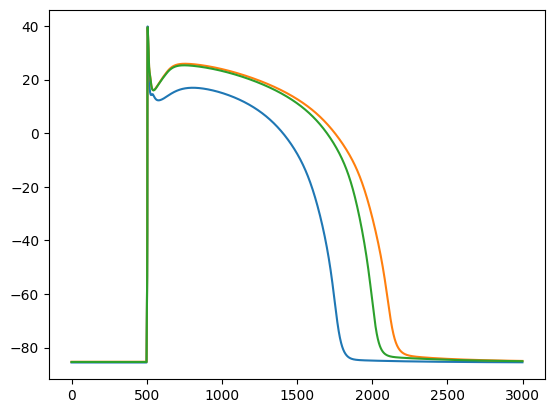

In [3]:
file = ['voltage_TNNP_pacingPeriod_1000_test2(verapamil).csv','voltage_TNNP_pacingPeriod_1000_test1(cisapride).csv','voltage_TNNP_pacingPeriod1000_APD_step_4.csv']
Vs = []
for f in file:
    U,S,V,currents_data, sorted_identifiability = readFile(f)
    plt.plot(currents_data['voltage'])
    Vs.append(V)
print(Vs[1] - Vs[2])

In [4]:
Vs[0]

array([[ 9.99998087e-01, -9.17123854e-04,  1.08959301e-03,
        -2.75337431e-06, -3.34704627e-04, -1.07049029e-03,
        -2.51962425e-05, -6.92825206e-05, -6.72553025e-04,
         2.67429731e-04, -5.78630827e-05,  7.80201308e-05],
       [-1.53767787e-03, -7.86144129e-01,  5.96703349e-01,
        -3.92717146e-02, -8.75309131e-02, -1.12816795e-01,
        -5.60984841e-02, -1.12862471e-02, -1.11557490e-02,
         2.07611704e-02, -1.12344614e-02,  5.70007791e-03],
       [ 8.17772797e-04, -5.40883588e-01, -5.79126061e-01,
         2.21352558e-01,  7.91824799e-02,  4.34501887e-01,
         1.90477627e-01, -1.36594403e-01,  2.34820698e-01,
        -1.16984795e-01,  5.27308085e-02, -3.81060629e-02],
       [ 5.18243668e-04,  2.44687682e-01,  3.75589332e-01,
        -5.09621710e-02, -4.40420912e-02,  2.01171123e-01,
         1.42035534e-01, -4.40191635e-01,  7.13806632e-01,
        -1.63042944e-01,  2.00875045e-02, -6.00372187e-02],
       [-1.27476007e-04,  3.97945560e-02,  8.9298376

In [5]:
Vs[1][7]

array([ 6.18215880e-04,  3.08322759e-02,  6.04208232e-02,  1.65105622e-02,
       -3.67192108e-02,  4.16618609e-01, -6.24693200e-01,  4.98953551e-01,
        2.31944523e-01, -3.37783644e-01, -1.89826407e-02, -1.12932348e-01])

In [6]:
Vs[2][7]

array([-4.12209705e-04, -4.80132067e-02, -5.25833231e-02, -3.12059751e-01,
       -1.19992598e-01, -8.70849616e-02,  7.01533831e-01, -3.88750491e-01,
       -4.71780931e-01,  9.21917857e-02,  2.00428291e-02,  2.84834423e-02])